# **Capstone Project — Telco Customer Churn Prediction**
#### **Course:** Data Science and Python

**Goal:** Predict whether a customer will churn (leave the company) using everything you've learned — Pandas, statistics, visualization, feature engineering, and machine learning.

For more details you can check project description file named *"Capstone_Project_Description.pdf"*.

**Dataset:** Telco Customer Churn (Kaggle) — download it from:
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Save the file as `WA_Fn-UseC_-Telco-Customer-Churn.csv` in the same folder as this notebook.

---


## **Step 1 — Setup & Exploratory Data Analysis (EDA)**

In [1]:
# Import the libraries we'll need throughout the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look a bit nicer
sns.set_style("whitegrid")
%matplotlib inline


In [2]:
# Load the dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Always start by looking at the shape and first few rows
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Check data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Descriptive statistics for numeric columns (Day 10 recap)
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
# Check for missing values in each column
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
# TotalCharges is often loaded as text (object) because of blank spaces.
# Let's check for that classic Telco Churn data-cleaning trap.
df["TotalCharges"].apply(type).value_counts()


TotalCharges
<class 'str'>    7043
Name: count, dtype: int64

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


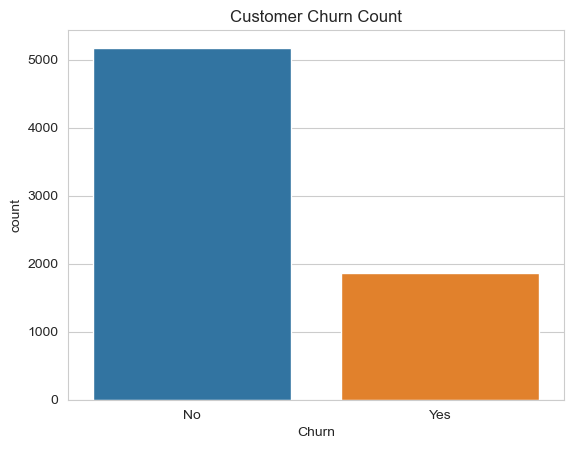

In [10]:
# Overall churn rate — our target variable balance
churn_rate = df["Churn"].value_counts(normalize=True) * 100
print(churn_rate)

sns.countplot(data=df, x="Churn", hue='Churn')
plt.title("Customer Churn Count")
plt.show()


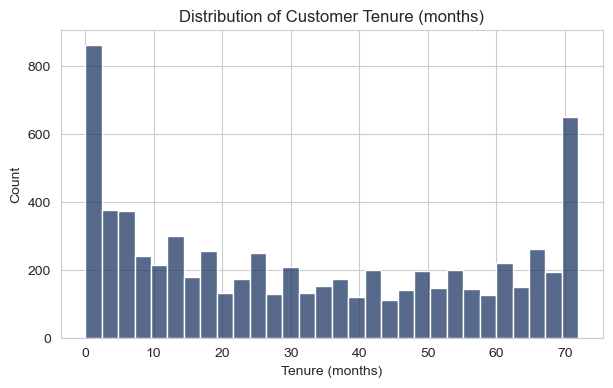

In [11]:
# Distribution of tenure (how long customers stay)
plt.figure(figsize=(7,4))
sns.histplot(df["tenure"], bins=30, color="#1F3864")
plt.title("Distribution of Customer Tenure (months)")
plt.xlabel("Tenure (months)")
plt.show()


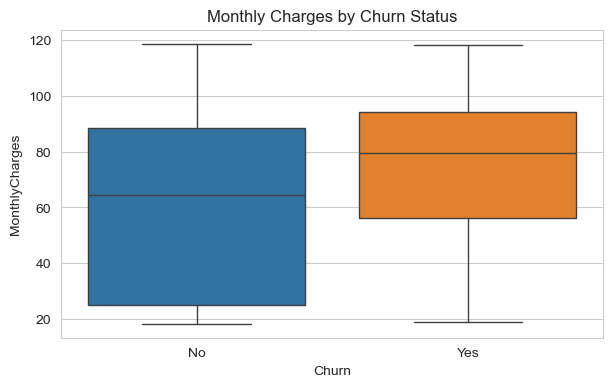

In [15]:
# Monthly charges by churn status — boxplot
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", hue="Churn")
plt.title("Monthly Charges by Churn Status")
plt.show()


**Discussion point (Correlation vs Causation):**
Customers with higher monthly charges ***tend to*** churn more — but that does not automatically mean high price ***causes*** churn.
It could also be linked to contract type, service quality, or customer expectations. Always ask "what else could explain this pattern?" before jumping to conclusions.


## **Step 2 — Data Cleaning & Feature Engineering**

In [16]:
# Step 1: Fix TotalCharges — convert to numeric, invalid entries become NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check how many values became missing
print("Missing TotalCharges after conversion:", df["TotalCharges"].isnull().sum())


Missing TotalCharges after conversion: 11


In [17]:
# Step 2: Handle the missing values.
# These are usually customers with tenure = 0 (brand new customers) — safe to fill with 0.
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Double check no missing values remain
df.isnull().sum().sum()


np.int64(0)

In [18]:
# Step 3: Drop columns that don't help prediction
df_model = df.drop(columns=["customerID"])

# Step 4: Convert target column to numeric (Yes -> 1, No -> 0)
df_model["Churn"] = df_model["Churn"].map({"Yes": 1, "No": 0})
df_model["Churn"].value_counts()


Churn
0    5174
1    1869
Name: count, dtype: int64

In [19]:
# Step 5: Encode categorical columns using one-hot encoding (Day 37)
categorical_cols = df_model.select_dtypes(include="object").columns.tolist()
print("Categorical columns to encode:", categorical_cols)

df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)
df_encoded.shape


Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


(7043, 31)

In [20]:
# Step 6: Scale numeric features (Day 38)
from sklearn.preprocessing import StandardScaler

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

df_encoded[numeric_cols].describe()


,tenure,MonthlyCharges,TotalCharges
count,7.043000e+03,7.043000e+03,7.043000e+03
mean,-2.421273e-17,-6.406285e-17,-3.783239e-17
std,1.000071e+00,1.000071e+00,1.000071e+00
min,-1.318165e+00,-1.545860e+00,-1.005780e+00
25%,-9.516817e-01,-9.725399e-01,-8.299464e-01
50%,-1.372744e-01,1.857327e-01,-3.905282e-01
75%,9.214551e-01,8.338335e-01,6.648034e-01
max,1.613701e+00,1.794352e+00,2.825806e+00


In [21]:
# Step 7: Split features (X) and target (y)
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (7043, 30)
Target shape: (7043,)


In [22]:
# Step 8: Train / Test split (Day 31)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 5634
Testing samples: 1409


## **Step 3 — Model Building**

In [23]:
# Model 1: Logistic Regression (Day 33) — our baseline model
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_test)
print("Logistic Regression trained successfully.")


Logistic Regression trained successfully.


In [24]:
# Model 2: Decision Tree Classifier (Day 34)
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

tree_preds = tree_model.predict(X_test)
print("Decision Tree trained successfully.")


Decision Tree trained successfully.


### **Bonus — K-Means Clustering**
This is not used for prediction — it's an extra way to discover natural customer *segments* based on tenure and monthly charges.


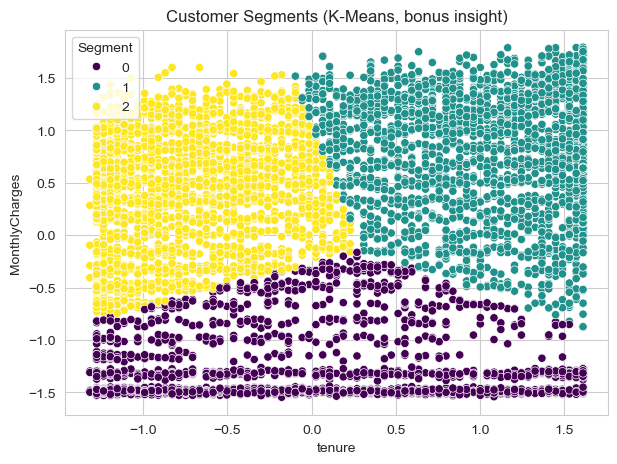

In [25]:
from sklearn.cluster import KMeans

cluster_features = df_encoded[["tenure", "MonthlyCharges"]]

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_encoded["Segment"] = kmeans.fit_predict(cluster_features)

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df_encoded, x="tenure", y="MonthlyCharges",
    hue="Segment", palette="viridis"
)
plt.title("Customer Segments (K-Means, bonus insight)")
plt.show()


## **Step 4 — Evaluation & Wrap-Up**

In [26]:
# Evaluate both models (Day 35)
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

def evaluate(name, y_true, y_pred):
    print(f"--- {name} ---")
    print("Accuracy: ", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3))
    print("Recall:   ", round(recall_score(y_true, y_pred), 3))
    print()

evaluate("Logistic Regression", y_test, log_preds)
evaluate("Decision Tree", y_test, tree_preds)


--- Logistic Regression ---
Accuracy:  0.806
Precision: 0.659
Recall:    0.559

--- Decision Tree ---
Accuracy:  0.794
Precision: 0.631
Recall:    0.54



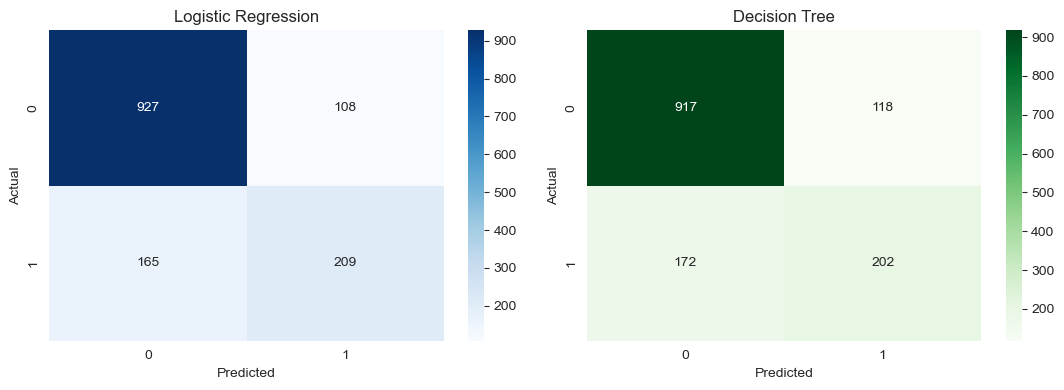

In [27]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(11,4))

sns.heatmap(confusion_matrix(y_test, log_preds), annot=True, fmt="d",
            cmap="Blues", ax=axes[0])
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, tree_preds), annot=True, fmt="d",
            cmap="Greens", ax=axes[1])
axes[1].set_title("Decision Tree")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


**Which metric matters most here?**

For churn prediction, missing a customer who is about to leave (a *false negative*) is usually more costly than wrongly flagging a loyal customer (a *false positive*) — because a missed churner is lost revenue with no chance to intervene.
That means **Recall** is often more important than plain Accuracy for this business problem. Compare the recall scores above and decide which model you would recommend to the business, and why.


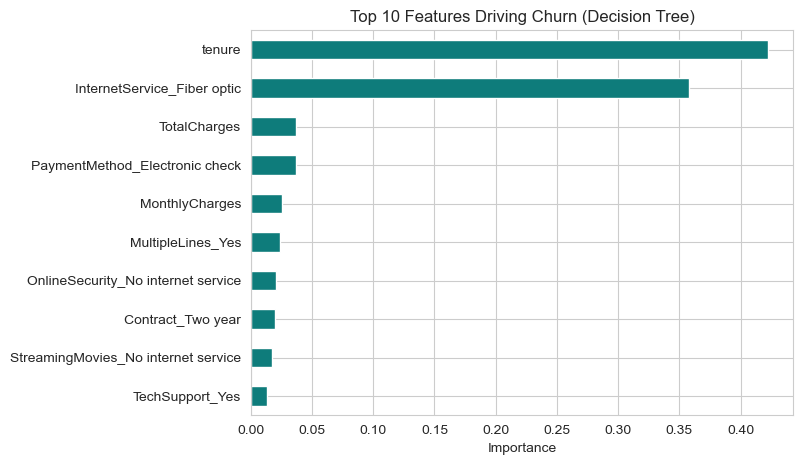

In [28]:
# Feature importance from the Decision Tree — which factors drive churn the most?
importances = pd.Series(tree_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(7,5))
top_features.sort_values().plot(kind="barh", color="#0E7C7B")
plt.title("Top 10 Features Driving Churn (Decision Tree)")
plt.xlabel("Importance")
plt.show()


## **Final Summary (fill this in yourself)**

Replace the placeholders below with your own findings before submitting.

- **Problem:** Predicting which telecom customers are likely to churn.
- **Approach:** Cleaned the data, engineered features, trained Logistic Regression and Decision Tree models, and compared them using accuracy, precision, and recall.
- **Best model:** *(state which model performed better and why — mention the metric you prioritized)*
- **Key business insight:** *(e.g., "Month-to-month contract customers churn far more than customers on two-year contracts — the company should focus retention offers there.")*
- **Next step for the business:** *(one recommendation based on your findings)*
